# NN 다중분류 (흑백)
- MNIST 데이터셋

In [18]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.92 s (started: 2025-01-22 22:01:58 +00:00)


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import keras

time: 936 µs (started: 2025-01-22 22:02:02 +00:00)


In [20]:
from io import BytesIO
import requests

data_url = 'https://raw.githubusercontent.com/20161609/data_box/main/mnist.npz'

# URL에서 파일 다운로드 후 메모리에 로드
response = requests.get(data_url)
if response.status_code == 200:
    npz_data = BytesIO(response.content)  # 메모리에 로드
    df = np.load(npz_data)  # numpy로 파일 읽기

    # npz 파일의 내용 확인
    print("npz 파일에 포함된 키:", df.files)
    print("x_train shape:", df['x_train'].shape)
    print("y_train shape:", df['y_train'].shape)
else:
    print("파일 다운로드 실패:", response.status_code)

npz 파일에 포함된 키: ['x_test', 'x_train', 'y_train', 'y_test']
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
time: 394 ms (started: 2025-01-22 22:02:02 +00:00)


## 1.데이터 준비

In [21]:
X_train = df['x_train']
X_test = df['x_test']
y_train = df['y_train']
y_test = df['y_test']

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

time: 295 ms (started: 2025-01-22 22:02:02 +00:00)


## 2.데이터 확인

In [22]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

time: 4.69 ms (started: 2025-01-22 22:02:02 +00:00)


In [23]:
# np.random.seed(42)
sample = np.random.randint(60000, size=25)
sample

array([39477, 36437, 25727, 24238, 24984, 43035, 31001,  6775, 56250,
       34471, 42075, 42792, 27345,   545, 33052, 43609,  4478, 18763,
       25927, 39852, 17396, 23362, 47238, 53752, 58594])

time: 4.68 ms (started: 2025-01-22 22:02:02 +00:00)


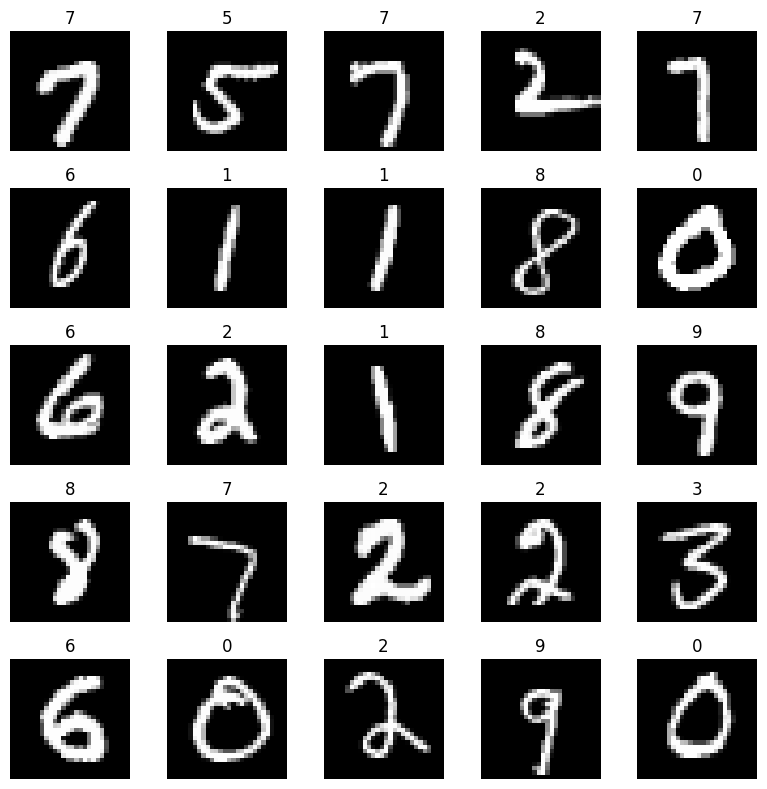

time: 1.31 s (started: 2025-01-22 22:02:02 +00:00)


In [24]:
fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(y_train[idx])
fig.tight_layout()
plt.show()

In [25]:
sr = pd.Series(y_train).value_counts().sort_index()
sr

,count
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


time: 20.3 ms (started: 2025-01-22 22:02:04 +00:00)


<BarContainer object of 10 artists>

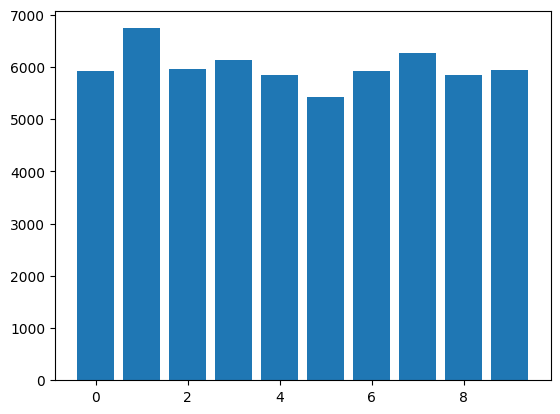

time: 237 ms (started: 2025-01-22 22:02:04 +00:00)


In [26]:
plt.bar(sr.index, sr)

## 3.학습용, 검증용 데이터 분리

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(48000, 28, 28) (12000, 28, 28)
(48000,) (12000,)
time: 38.7 ms (started: 2025-01-22 22:02:04 +00:00)


## 4.전처리
- X값은 스케일링
- y는 원핫인코딩

In [28]:
# Min-Max Scaling

X_train_s = X_train / 255.
X_val_s = X_val / 255.

time: 272 ms (started: 2025-01-22 22:02:04 +00:00)


In [29]:
# y의 원핫인코딩
from keras.utils import to_categorical

y_train_o = to_categorical(y_train)
y_val_o = to_categorical(y_val)

time: 8.62 ms (started: 2025-01-22 22:02:04 +00:00)


In [30]:
y_train_o.shape, y_val_o.shape

((48000, 10), (12000, 10))

time: 6.54 ms (started: 2025-01-22 22:02:04 +00:00)


In [31]:
y_train_o[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

time: 6.83 ms (started: 2025-01-22 22:02:04 +00:00)


In [32]:
print(X_train_s.shape, X_val_s.shape)
print(y_train_o.shape, y_val_o.shape)

(48000, 28, 28) (12000, 28, 28)
(48000, 10) (12000, 10)
time: 7.32 ms (started: 2025-01-22 22:02:04 +00:00)


## 5.모델

In [33]:
X_train_s = X_train_s.reshape(-1, 28*28)
X_val_s = X_val_s.reshape(-1, 28*28)

time: 389 µs (started: 2025-01-22 22:02:04 +00:00)


In [34]:
X_train_s.shape

(48000, 784)

time: 3.97 ms (started: 2025-01-22 22:02:04 +00:00)


In [35]:
y_train_o.shape

(48000, 10)

time: 3.64 ms (started: 2025-01-22 22:02:04 +00:00)


In [36]:
from keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

time: 202 ms (started: 2025-01-22 22:02:04 +00:00)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,018 (207.10 KB)

 Trainable params: 53,018 (207.10 KB)

 Non-trainable params: 0 (0.00 B)

time: 623 ms (started: 2025-01-22 22:02:05 +00:00)


In [38]:
adam = keras.optimizers.Adam(learning_rate=0.01)

model.compile(
    loss='categorical_crossentropy',
    optimizer=adam,
    metrics=['accuracy']
)

time: 20 ms (started: 2025-01-22 22:02:05 +00:00)


In [39]:
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train_o,
                    epochs = EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data = (X_val_s, y_val_o))


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8499 - loss: 0.4785 - val_accuracy: 0.9307 - val_loss: 0.2508
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9474 - loss: 0.1891 - val_accuracy: 0.9361 - val_loss: 0.2363
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9557 - loss: 0.1584 - val_accuracy: 0.9572 - val_loss: 0.1631
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9593 - loss: 0.1467 - val_accuracy: 0.9552 - val_loss: 0.1793
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9639 - loss: 0.1319 - val_accuracy: 0.9548 - val_loss: 0.1802
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9638 - loss: 0.1296 - val_accuracy: 0.9588 - val_loss: 0.1875
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9699 - loss: 0.1199 - val_accuracy: 0.9554 - val_loss: 0.1970
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9693 - loss: 0.1165

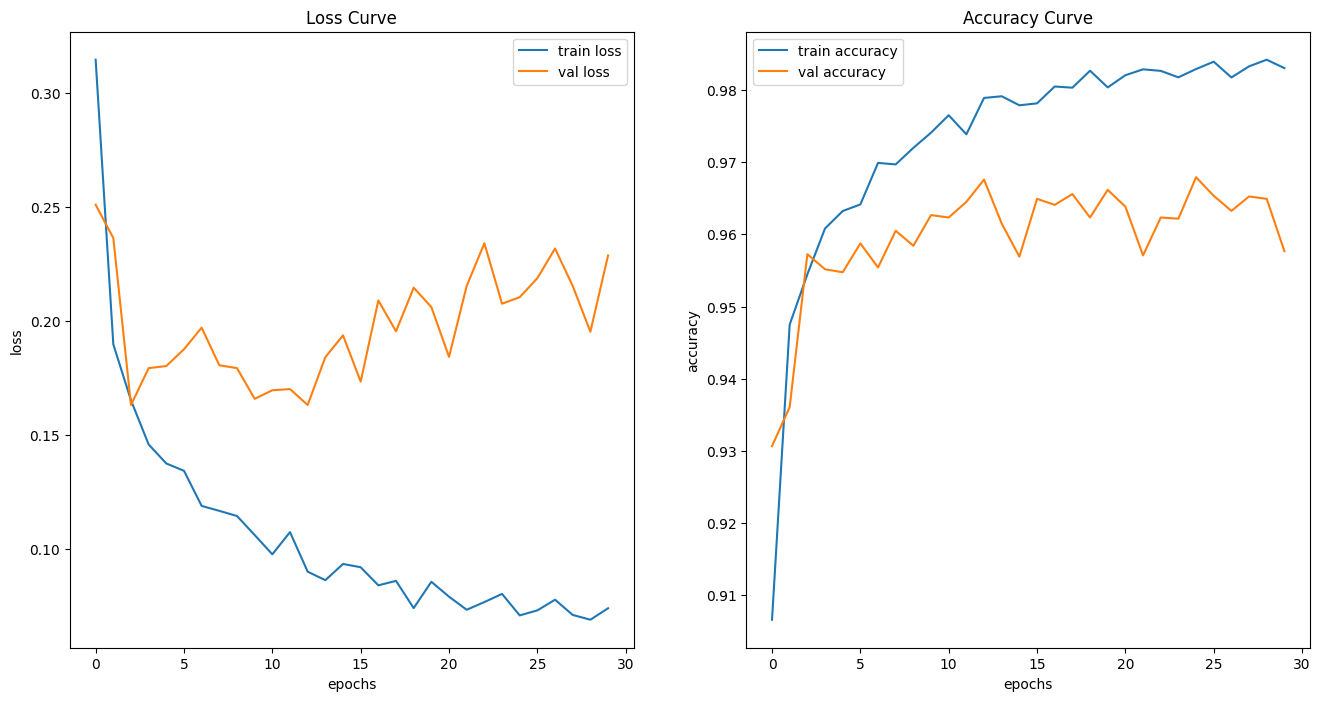

time: 781 ms (started: 2025-01-22 22:05:00 +00:00)


In [40]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

## 6.평가

In [41]:
X_test_s = X_test / 255.
X_test_s = X_test_s.reshape(-1, 28*28)
y_test_o = to_categorical(y_test)

time: 74.5 ms (started: 2025-01-22 22:05:01 +00:00)


In [42]:
X_test_s.shape, y_test_o.shape

((10000, 784), (10000, 10))

time: 3.39 ms (started: 2025-01-22 22:05:01 +00:00)


In [43]:
y_pred = model.predict(X_test_s)

y_pred[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.35770172e-23, 2.87123138e-11, 1.95996414e-18, 5.18500546e-15,
        2.03166235e-23, 1.48113587e-14, 0.00000000e+00, 9.99999940e-01,
        0.00000000e+00, 5.21254119e-19],
       [9.02605055e-23, 3.20323771e-14, 9.99999940e-01, 7.27328151e-14,
        8.55424889e-13, 3.30684496e-24, 3.65564099e-24, 8.14706677e-19,
        6.40891525e-20, 8.76806630e-29],
       [0.00000000e+00, 9.99999940e-01, 4.51109813e-18, 1.10526698e-21,
        1.21877369e-23, 2.43680849e-31, 1.18932821e-24, 4.65447334e-18,
        6.28655095e-16, 6.18852072e-31],
       [9.99993384e-01, 1.68893810e-27, 3.88970918e-08, 5.55544115e-19,
        6.00047221e-20, 1.06708533e-15, 4.08175993e-10, 1.03869000e-24,
        6.50883976e-06, 4.93895994e-13],
       [2.52773690e-15, 9.65315621e-07, 3.21195171e-06, 3.36108501e-14,
        9.99178469e-01, 2.39452214e-09, 3.67892608e-06, 9.05187449e-07,
        1.41878109e-08, 8.12646293e-04],
       [0.00000000e+00, 9.99999940e-01, 1.95041744e-18, 3.99980626e-22,
   

time: 1.17 s (started: 2025-01-22 22:05:01 +00:00)


In [44]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

time: 4.1 ms (started: 2025-01-22 22:05:02 +00:00)


In [45]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred ,average=aver))
    print('precision:', precision_score(y_true, y_pred,average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

time: 3.91 ms (started: 2025-01-22 22:05:02 +00:00)


accuracy: 0.9587
recall: 0.9577082024607328
precision: 0.960601590440396
f1 : 0.95841998552547


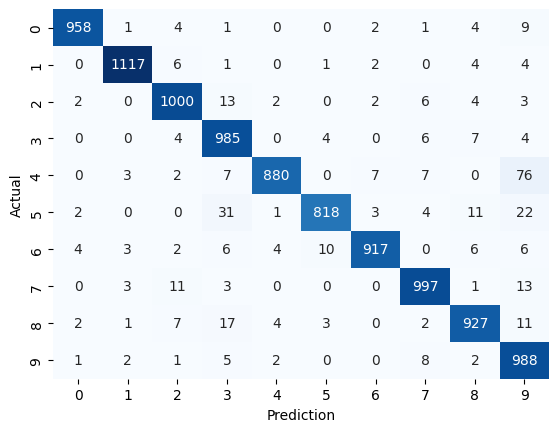

time: 464 ms (started: 2025-01-22 22:05:02 +00:00)


In [46]:
print_metrics(y_test, y_pred, aver='macro')

In [47]:
X_test.shape

(10000, 28, 28)

time: 5.15 ms (started: 2025-01-22 22:05:03 +00:00)


In [48]:
sample = np.random.randint(10000, size=25)
sample

array([ 361, 1984, 6821, 5064, 8631, 4499, 3971, 5666, 8211, 2997, 2406,
       3767, 1011,  523, 8005,  778, 4297, 3426, 1141, 5556, 3674, 6294,
       2195, 3549, 7858])

time: 6.35 ms (started: 2025-01-22 22:05:03 +00:00)


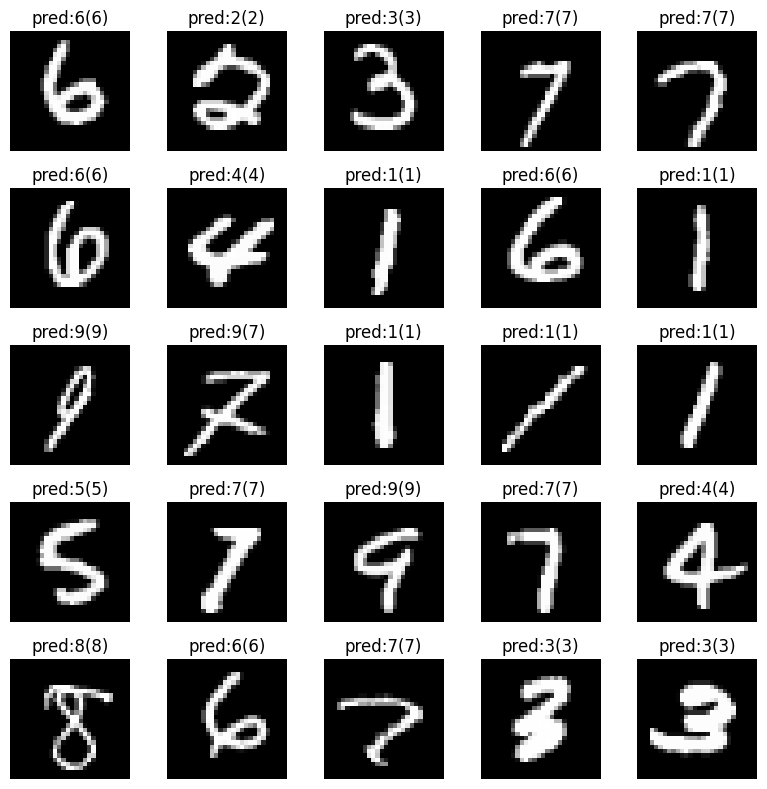

time: 1.44 s (started: 2025-01-22 22:05:03 +00:00)


In [49]:
fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.axis('off')
    plt.title(f'pred:{y_pred[idx]}({y_test[idx]})')
fig.tight_layout()
plt.show()

time: 1.45 s (started: 2025-01-22 22:05:03 +00:00)
